# 7DS Origin Launch Analysis

| Field | Value |
|-------|-------|
| **Author** | Haewon |
| **Last update** | 2026-03-10 |
| **Objective** | Benchmark and prepare targeting strategy for 7DS Origin — identify comparable heavy titles, map install→login gap events, and de-target low-spec devices that fail to complete the 9–16GB in-app packet download |
| **Scope** | (1) Heavy game identification via SensorTower, (2) Install→login gap event audit in BQ, (3) Campaign structure at launch for comparable titles, (4) Device/OS performance analysis for de-targeting |
| **Out of scope** | Post-login funnel analysis, creative performance, non-Moloco campaign data |
| **Key tables** | `moloco-ods.prod_stream.*` (events), campaign/ad group config tables, bid/spend tables |
| **Additional context** | Funnel: Install (300MB) → Game Start click → In-app packet (9–16GB) → Login. Target login CPA: KRW 15,000. Game launch: 2026-03-24. Analysis due: 2026-03-14. |

In [42]:
import os
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

In [53]:
client = bigquery.Client(project="moloco-ods")

def run_query(query, label=''):
    df = client.query(query).result().to_dataframe()
    print(f'✅ {label}: {len(df)} rows')
    return df

# Parameters
TARGET_LOGIN_CPA_KRW = 15000
LAUNCH_DATE = '2026-03-24'
ANALYSIS_DATE = '2026-03-10'

## Section 1 — Heavy Game Identification (SensorTower)

**Goal:** Find games with ≥3GB iOS file size launched after 2025-07-01 in Action/Strategy genres, as benchmarks for 7DS Origin's heavy download profile.

**Approach:**
- iOS App File Size is a website-only filter in SensorTower (not exportable as a column)
- Pre-filtered export: **3GB–5GB** bucket selected (no >5GB titles exist under Action/Strategy + release ≥ 2025-07-01)
- Genre = Action or Strategy, release date ≥ 2025-07-01
- Result: **17 titles** → cleaned, sorted by release date, bundle IDs to be mapped for BQ sections

**Output:** `heavy_titles_list.csv`

In [44]:
# Update path to the exported SensorTower CSV (3GB-5GB + >5GB, Action/Strategy, release >= 2025-07-01)
ST_CSV_PATH = '~/Downloads/action_strategy_3-5G.csv'

df_st = pd.read_csv(ST_CSV_PATH, sep='\t', encoding='utf-16')
df_st.columns = df_st.columns.str.strip()
df_st['Release Date'] = pd.to_datetime(df_st['Release Date'], errors='coerce')

print(f'Raw rows: {len(df_st)}')
df_st.head(3)

Raw rows: 39


,Unified ID,Unified Name,Unified Publisher,Unified Publisher Name,Category,Last Updated,Release Date,Search Match
0,663c8be76018ac20a852f67b,Where Winds Meet,560c44888ac35064390048b9,NetEase,"Games, Games/Role Playing",2026-03-07,2025-01-07,NaN
1,692f08a068cf8e6e27ddd4cb,Red Dead Redemption,5614b32f3f07e2077c000488,Take-Two Interactive,"Games, Games/Action, Games/Adventure",2026-03-04,2025-12-04,NaN
2,691fce659feb3ebb3a7900a3,Arknights: Endfield,65b40895950aa435105b739f,Hypergryph,"Role Playing, Game",2026-01-10,2026-01-10,NaN


In [45]:
# Filter: release date >= 2025-07-01 (already pre-filtered in ST, but enforce here)
df_heavy = df_st[df_st['Release Date'] >= '2025-07-01'].copy()

# Filter: Action or Strategy genre
genre_mask = df_heavy['Category'].str.contains('Action|Strategy', case=False, na=False)
df_heavy = df_heavy[genre_mask].copy()

# Clean up columns
df_heavy = df_heavy.rename(columns={
    'Unified ID': 'unified_id',
    'Unified Name': 'app_name',
    'Unified Publisher Name': 'publisher',
    'Category': 'category',
    'Release Date': 'release_date',
    'Last Updated': 'last_updated',
})

df_heavy = df_heavy[['unified_id', 'app_name', 'publisher', 'category', 'release_date', 'last_updated']].reset_index(drop=True)

# Note: iOS file size bucket is a pre-export filter (3GB-5GB or >5GB) — all rows here meet that criteria
df_heavy['ios_file_size_bucket'] = '>=3GB'  # placeholder; split into buckets if two separate exports

print(f'Heavy titles (>=3GB, Action/Strategy, post 2025-07): {len(df_heavy)}')
df_heavy

Heavy titles (>=3GB, Action/Strategy, post 2025-07): 17


,unified_id,app_name,publisher,category,release_date,last_updated,ios_file_size_bucket
0,692f08a068cf8e6e27ddd4cb,Red Dead Redemption,Take-Two Interactive,"Games, Games/Action, Games/Adventure",2025-12-04,2026-03-04,>=3GB
1,64efb686dcf7af470489eb89,Rainbow Six Mobile,Ubisoft,"Games, Games/Action",2026-02-23,2026-03-05,>=3GB
2,6838fcfb0c4851bac2097fb0,Destiny: Rising,NetEase,"Games, Games/Action, Games/Adventure",2025-08-31,2026-01-22,>=3GB
3,68e85f7dc279e70adf9b7307,BLEACH: Soul Resonance,ByteDance,"Games, Games/Role Playing, Games/Action",2025-11-20,2026-02-04,>=3GB
4,6809e8dfb05f4cbbdac47909,Blue Protocol: Star Resonance,XD,"Games, Games/Role Playing, Games/Action",2025-12-17,2025-12-10,>=3GB
5,68cc24bbe62f9441888a7c93,Stella Sora,Yostar,"Games, Games/Role Playing, Games/Action",2025-10-19,2025-12-23,>=3GB
6,67acb7045d25a7783c5327ba,Mecharashi,TenTree Games,"Strategy, Game",2025-07-24,2026-02-13,>=3GB
7,68acd646065944165ec035ad,HITMAN World of Assassination,IO Interactive A/S,"Games, Games/Action, Games/Simulation",2025-08-27,2026-02-25,>=3GB
8,69400056f2095209dc16393a,Three Kingdoms: World Conquest,Rastar,"Games, Games/Strategy, Entertainment, Games/Ro...",2026-01-22,2026-02-12,>=3GB
9,694cc8588d09d7904a1d52e4,Thiếu Niên 3Q: Khởi Nguyên,Appota,"Strategy, Game",2026-01-21,2026-02-13,>=3GB


In [46]:
# Genre distribution
genre_counts = (
    df_heavy['category']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)
print('Genre breakdown:')
print(genre_counts.to_string())

Genre breakdown:
category
Games                 14
Games/Action          11
Games/Role Playing     7
Games/Adventure        3
Game                   3
Games/Strategy         3
Strategy               2
Entertainment          2
Games/Simulation       1
Action                 1


In [47]:
# Release date distribution (monthly)
df_heavy['release_month'] = df_heavy['release_date'].dt.to_period('M').astype(str)
monthly = df_heavy.groupby('release_month').size().reset_index(name='count').sort_values('release_month')

fig = px.bar(monthly, x='release_month', y='count',
             title='Heavy Titles Released per Month (3GB-5GB iOS, Action/Strategy)',
             labels={'release_month': 'Month', 'count': 'App Count'})
fig.update_xaxes(type='category')
fig.show()

monthly

,release_month,count
0,2025-07,1
1,2025-08,5
2,2025-10,1
3,2025-11,2
4,2025-12,3
5,2026-01,3
6,2026-02,2


In [48]:
# Save output
df_heavy.to_csv('heavy_titles_list.csv', index=False)
print(f'✅ Saved heavy_titles_list.csv ({len(df_heavy)} titles)')

# Extract unified IDs for downstream sections
# Note: SensorTower Unified ID ≠ bundle ID. Bundle IDs needed for BQ — map manually or via ST app detail.
HEAVY_TITLE_UNIFIED_IDS = df_heavy['unified_id'].tolist()
print(f'\nUnified IDs for BQ lookup ({len(HEAVY_TITLE_UNIFIED_IDS)} titles):')
print(HEAVY_TITLE_UNIFIED_IDS[:10], '...' if len(HEAVY_TITLE_UNIFIED_IDS) > 10 else '')

✅ Saved heavy_titles_list.csv (17 titles)

Unified IDs for BQ lookup (17 titles):
['692f08a068cf8e6e27ddd4cb', '64efb686dcf7af470489eb89', '6838fcfb0c4851bac2097fb0', '68e85f7dc279e70adf9b7307', '6809e8dfb05f4cbbdac47909', '68cc24bbe62f9441888a7c93', '67acb7045d25a7783c5327ba', '68acd646065944165ec035ad', '69400056f2095209dc16393a', '694cc8588d09d7904a1d52e4'] ...


### Section 1b — Bundle ID Lookup via BQ App Dimension Table

Map SensorTower Unified IDs → Android bundle IDs + iOS App Store IDs using `moloco-ae-view.athena.dim1_app`.

In [49]:
# Bundle ID lookup via BQ app dimension table
# Table: moloco-ae-view.athena.dim1_app
# Group by unified_app_id only — avoids row duplication from multi-locale app names

query_bundle_ids = f"""
WITH unified_ids AS (
  SELECT id
  FROM UNNEST({HEAVY_TITLE_UNIFIED_IDS}) AS id
)
SELECT
  sensortower.unified_app_id,
  MAX(COALESCE(sensortower.app_name, dataai.app_name, matters42.app_name)) AS app_name,
  MAX(IF(os = 'ANDROID', app_market_bundle, NULL)) AS android_bundle_id,
  MAX(IF(os = 'IOS',     app_market_bundle, NULL)) AS ios_app_store_id
FROM `moloco-ae-view.athena.dim1_app`
WHERE sensortower.unified_app_id IN (SELECT id FROM unified_ids)
GROUP BY sensortower.unified_app_id
ORDER BY app_name
"""

df_bundle_ids = run_query(query_bundle_ids, label='Bundle ID lookup')
df_bundle_ids

✅ Bundle ID lookup: 12 rows


,unified_app_id,app_name,android_bundle_id,ios_app_store_id
0,68acd646065944165ec035ad,HITMAN World of Assassination,None,6742786366
1,67acb7045d25a7783c5327ba,Mecharashi,com.tentree.gp.un.mecharashi,6670385152
2,691961c8b320f50dd8af8de6,Miiridian Prime,com.miiridianprime,6753178272
3,6825418f28239ec08c5b2a5b,Moonray: Battle Lands,game.moonray.battlelands,6748650910
4,64efb686dcf7af470489eb89,Rainbow Six Mobile,com.ubisoft.rainbowsixmobile.r6.fps.pvp.shooter,1608916511
5,683f940547e09ea2f02e0cd8,The Braves - Isekai Survivor,com.braves.survivor.isekai.io,6743005185
6,6838fcfb0c4851bac2097fb0,天命：群星,com.netease.g108na,6744052056
7,61e1525e13352d2208adb12a,幻唐志官方助手,None,1595550587
8,6809e8dfb05f4cbbdac47909,星痕共鸣,None,6743318344
9,67550550ea8990fe7f2d9704,魔狩战纪,None,6504311594


In [50]:
# Merge bundle IDs back into df_heavy
# Drop existing bundle ID columns first in case this cell is re-run
df_heavy = df_heavy.drop(columns=['android_bundle_id', 'ios_app_store_id', 'unified_app_id'], errors='ignore')

df_heavy = df_heavy.merge(
    df_bundle_ids[['unified_app_id', 'android_bundle_id', 'ios_app_store_id']],
    left_on='unified_id', right_on='unified_app_id', how='left'
).drop(columns='unified_app_id')

print(f'Rows: {len(df_heavy)} (expect 17)')
print(f'Matched: {df_heavy["android_bundle_id"].notna().sum()}/{len(df_heavy)} Android, '
      f'{df_heavy["ios_app_store_id"].notna().sum()}/{len(df_heavy)} iOS')

df_heavy[['app_name', 'android_bundle_id', 'ios_app_store_id']]

Rows: 17 (expect 17)
Matched: 8/17 Android, 12/17 iOS


,app_name,android_bundle_id,ios_app_store_id
0,Red Dead Redemption,NaN,NaN
1,Rainbow Six Mobile,com.ubisoft.rainbowsixmobile.r6.fps.pvp.shooter,1608916511
2,Destiny: Rising,com.netease.g108na,6744052056
3,BLEACH: Soul Resonance,com.bladetw.bd,6745081346
4,Blue Protocol: Star Resonance,None,6743318344
5,Stella Sora,com.YoStarKR.StellaSora,6738902933
6,Mecharashi,com.tentree.gp.un.mecharashi,6670385152
7,HITMAN World of Assassination,None,6742786366
8,Three Kingdoms: World Conquest,NaN,NaN
9,Thiếu Niên 3Q: Khởi Nguyên,NaN,NaN


### Section 1c — Moloco Spend During Launch Phase (D0–D30)

Check whether these heavy titles ran on Moloco during their launch window, and how much they spent.

In [51]:
# Build UNNEST struct string — one row per (bundle_id, os) per app
# Apps with both Android + iOS IDs generate two rows
def build_app_tuples(df):
    rows = []
    for _, r in df.iterrows():
        release_date = pd.Timestamp(r['release_date']).strftime('%Y-%m-%d')
        if pd.notna(r.get('android_bundle_id')):
            rows.append(f"    STRUCT('{r['android_bundle_id']}' AS bundle_id, 'ANDROID' AS os, DATE('{release_date}') AS release_date, '{r['app_name']}' AS app_name)")
        if pd.notna(r.get('ios_app_store_id')):
            rows.append(f"    STRUCT('{r['ios_app_store_id']}' AS bundle_id, 'IOS' AS os, DATE('{release_date}') AS release_date, '{r['app_name']}' AS app_name)")
    return ',\n'.join(rows)

app_tuples_str = build_app_tuples(df_heavy)
print(f'App/OS combinations to check: {app_tuples_str.count("STRUCT")}')

query_launch_spend = f"""
WITH app_list AS (
  SELECT *
  FROM UNNEST([
{app_tuples_str}
  ]) AS t(bundle_id STRING, os STRING, release_date DATE, app_name STRING)
)
SELECT
  a.app_name,
  a.bundle_id,
  a.os,
  a.release_date,
  COALESCE(SUM(f.gross_spend_usd), 0)                                        AS total_spend_usd,
  COUNT(DISTINCT CASE WHEN f.gross_spend_usd > 0 THEN f.date_utc END)        AS spend_days,
  MIN(CASE WHEN f.gross_spend_usd > 0 THEN f.date_utc END)                   AS first_spend_date
FROM app_list a
LEFT JOIN `moloco-ae-view.athena.fact_dsp_core` f
  ON  f.advertiser.mmp_bundle_id = a.bundle_id
  AND f.campaign.os = a.os
  AND f.date_utc BETWEEN a.release_date AND DATE_ADD(a.release_date, INTERVAL 30 DAY)
WHERE f.date_utc BETWEEN (SELECT MIN(release_date) FROM app_list)
                     AND (SELECT DATE_ADD(MAX(release_date), INTERVAL 30 DAY) FROM app_list)
GROUP BY a.app_name, a.bundle_id, a.os, a.release_date
ORDER BY total_spend_usd DESC
"""

df_launch_spend = run_query(query_launch_spend, label='Launch spend (D0–D30)')
df_launch_spend

App/OS combinations to check: 20


BadRequest: 400 Syntax error: Expected ")" but got "(" at [25:10]; reason: invalidQuery, location: query, message: Syntax error: Expected ")" but got "(" at [25:10]

Location: US
Job ID: 1e3a46a0-63d0-489b-8f2d-84ba601b7262


## Section 1-2 — Heavy Game Identification (Alternative: Post-Install Gap Events via BQ)

**Motivation:** SensorTower's iOS App File Size reflects the initial store download (~300MB), not the in-app asset packet downloaded after first launch (e.g., 9–16GB for 7DS Origin). This section identifies comparable heavy-download titles directly from event behavior.

**Approach:**
- Scope: gaming apps released in the past 6 months with Moloco spend in D0–D30
- Signal 1: presence of intermediate events between install and login (`has_gap_events`)
- Signal 2: median install→login time — heavy download games show 5–30+ min gaps

**Tables:**
- `focal-elf-631.df_accesslog.pb` — postback events (install, login, gap events)
- `moloco-ae-view.athena.dim1_app` — app metadata, release date, gaming flag
- `moloco-ae-view.athena.fact_dsp_core` — D0–D30 spend filter

**⚠️ Cost note:** pb table is ~1TB/day. The INNER JOIN to qualifying bundles reduces scan, but test on a narrow date range first if needed.

In [86]:
ANALYSIS_DATE = '2026-03-10'

# Step 1-3: Qualifying apps — RPG/Strategy released past 6mo, Moloco D0-D30 DRR > $500/day
# This is the fast part (dim1_app + fact_dsp_core only, no pb)
query_qualifying_apps = f"""
WITH
recently_released_games AS (
  SELECT
    app_market_bundle,
    os,
    CASE WHEN os = 'IOS' THEN CONCAT('id', app_market_bundle) ELSE app_market_bundle END AS mmp_bundle_id,
    COALESCE(dataai.app_name, sensortower.app_name) AS app_name,
    dataai.app_release_date_utc AS release_date,
    moloco.genre AS moloco_genre
  FROM `moloco-ae-view.athena.dim1_app`
  WHERE moloco.genre IN ('rpg', 'strategy')
    AND dataai.app_release_date_utc >= DATE_SUB(DATE '{ANALYSIS_DATE}', INTERVAL 12 MONTH)
    AND dataai.app_release_date_utc <= DATE '{ANALYSIS_DATE}'
),
apps_with_spend AS (
  SELECT
    f.product.app_market_bundle AS bundle_id,
    f.campaign.os,
    SUM(f.gross_spend_usd) AS d0_d30_spend_usd
  FROM `moloco-ae-view.athena.fact_dsp_core` f
  INNER JOIN recently_released_games g
    ON f.product.app_market_bundle = g.app_market_bundle
    AND f.campaign.os = g.os
  WHERE f.date_utc BETWEEN g.release_date AND DATE_ADD(g.release_date, INTERVAL 30 DAY)
    AND f.date_utc >= DATE_SUB(DATE '{ANALYSIS_DATE}', INTERVAL 12 MONTH)
    AND f.gross_spend_usd > 0
  GROUP BY 1, 2
  HAVING SUM(f.gross_spend_usd) > 15000
)
SELECT
  g.app_market_bundle AS bundle_id,
  g.mmp_bundle_id,
  g.os,
  g.app_name,
  g.release_date,
  g.moloco_genre,
  ROUND(s.d0_d30_spend_usd, 0) AS d0_d30_spend_usd
FROM recently_released_games g
INNER JOIN apps_with_spend s
  ON g.app_market_bundle = s.bundle_id
  AND g.os = s.os
ORDER BY g.app_name
"""

df_qualifying = run_query(query_qualifying_apps, label='Qualifying apps (Steps 1-3)')
print(f"\n{len(df_qualifying)} qualifying app/OS combos")
print(df_qualifying[['app_name', 'bundle_id', 'mmp_bundle_id', 'os', 'release_date']].to_string(index=False))

# Build explicit IN list for pb query
mmp_bundles = df_qualifying['mmp_bundle_id'].dropna().unique().tolist()
print(f"\n✅ {len(mmp_bundles)} unique MMP bundles for pb query")


✅ Qualifying apps (Steps 1-3): 112 rows

112 qualifying app/OS combos
                     app_name                     bundle_id                 mmp_bundle_id      os release_date
                        AION2                    1470173983                  id1470173983     IOS   2025-11-16
          Arknights: Endfield                    6752642477                  id6752642477     IOS   2026-01-19
          Blade & Soul Heroes                    6742443980                  id6742443980     IOS   2025-09-02
              Bonk Bonk Tribe                    6747027909                  id6747027909     IOS   2025-09-16
          Bиндpaйдep: Легенда                    6752983341                  id6752983341     IOS   2025-10-16
                 Chess Rumble                    6535669795                  id6535669795     IOS   2025-10-14
             Crystal of Atlan                    6742167253                  id6742167253     IOS   2025-05-26
             DC: Dark Legion™             

In [ ]:
# Gap event analysis via pb
# - 7-day window (~18 TB): wide enough to capture first-login journeys for fresh installs
# - qualifying_apps inlined from df_qualifying (cell 15) — no redundant dim1_app/fact_dsp_core scan
# - install_cohort uses install_at from any event to identify the install cohort within the window
# - first_login_rate_pct = login_users / install_users (cohort-based, not session-based)

PB_DAYS = 7

# Build UNNEST struct from df_qualifying (mirrors build_app_tuples pattern)
def build_qualifying_structs(df):
    rows = []
    for _, r in df.iterrows():
        name = str(r['app_name']).replace("'", "''")  # SQL-escape single quotes
        release = str(r['release_date'])[:10]
        row = (
            "    STRUCT("
            + f"'{r['bundle_id']}' AS bundle_id, "
            + f"'{r['mmp_bundle_id']}' AS mmp_bundle_id, "
            + f"'{r['os']}' AS os, "
            + f"'{name}' AS app_name, "
            + f"DATE('{release}') AS release_date, "
            + f"'{r['moloco_genre']}' AS moloco_genre, "
            + f"{r['d0_d30_spend_usd']} AS d0_d30_spend_usd"
            + ")"
        )
        rows.append(row)
    return ',\n'.join(rows)

qualifying_structs = build_qualifying_structs(df_qualifying)
mmp_bundles_in = ', '.join(f"'{b}'" for b in df_qualifying['mmp_bundle_id'].dropna().unique())

print(f"qualifying_apps: {len(df_qualifying)} rows, {len(df_qualifying['mmp_bundle_id'].dropna().unique())} unique MMP bundles")

query_gap_events = f"""
-- Heavy Download Game Detection: post-install gap event analysis
-- qualifying_apps: inlined from Python (no redundant dim1_app/fact_dsp_core scan)
-- pb window: {PB_DAYS} days + explicit bundle IN list

WITH

qualifying_apps AS (
  SELECT *
  FROM UNNEST([
{qualifying_structs}
  ]) AS t
),

-- pb: {PB_DAYS}-day window, explicit bundle IN list for faster execution
pb_events AS (
  SELECT
    qa.bundle_id,
    qa.os,
    CASE
      WHEN pb.device.idfa NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN pb.device.idfa
      WHEN pb.device.idfv NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN pb.device.idfv
      WHEN pb.mmp.device_id IS NOT NULL AND pb.mmp.device_id != '' THEN pb.mmp.device_id
      ELSE NULL
    END AS user_id,
    pb.event.name       AS event_name,
    pb.event.event_at   AS event_at,
    pb.event.install_at AS install_at
  FROM `focal-elf-631.df_accesslog.pb` pb
  INNER JOIN qualifying_apps qa ON pb.app.bundle = qa.mmp_bundle_id
  WHERE DATE(pb.timestamp) BETWEEN DATE_SUB(DATE '{ANALYSIS_DATE}', INTERVAL {PB_DAYS} DAY) AND DATE '{ANALYSIS_DATE}'
    AND pb.attribution.attributed = TRUE
    AND pb.app.bundle IN ({mmp_bundles_in})
),

user_installs AS (
  SELECT bundle_id, os, user_id,
    MIN(COALESCE(install_at, event_at)) AS install_time
  FROM pb_events
  WHERE event_name = 'install' AND user_id IS NOT NULL
  GROUP BY 1, 2, 3
),

user_logins AS (
  SELECT bundle_id, os, user_id,
    MIN(event_at) AS first_login_time
  FROM pb_events
  WHERE LOWER(event_name) LIKE '%login%' AND user_id IS NOT NULL
  GROUP BY 1, 2, 3
),

-- Install cohort: users whose install_at falls within the pb window, derived from ANY event
-- Using install_at (not just install events) captures users who installed recently
-- but whose install event may not have been forwarded in this window
install_cohort AS (
  SELECT bundle_id, os, user_id,
    MIN(install_at) AS install_time
  FROM pb_events
  WHERE install_at IS NOT NULL
    AND install_at >= TIMESTAMP(DATE_SUB(DATE '{ANALYSIS_DATE}', INTERVAL {PB_DAYS} DAY))
    AND user_id IS NOT NULL
  GROUP BY 1, 2, 3
),

-- Install-to-first-login rate: cohort = users who installed within the pb window
-- login_users = subset of that cohort who also had a first login event in the window
install_login_rate AS (
  SELECT
    c.bundle_id, c.os,
    COUNT(DISTINCT c.user_id) AS install_users,
    COUNT(DISTINCT l.user_id) AS login_users
  FROM install_cohort c
  LEFT JOIN user_logins l USING (bundle_id, os, user_id)
  GROUP BY 1, 2
),

user_journey AS (
  SELECT
    i.bundle_id, i.os, i.user_id,
    i.install_time, l.first_login_time,
    TIMESTAMP_DIFF(l.first_login_time, i.install_time, MINUTE) AS install_to_login_min
  FROM user_installs i
  INNER JOIN user_logins l USING (bundle_id, os, user_id)
  WHERE l.first_login_time > i.install_time
    AND TIMESTAMP_DIFF(l.first_login_time, i.install_time, MINUTE) BETWEEN 1 AND 1440
),

gap_events AS (
  SELECT e.bundle_id, e.os, e.user_id, e.event_name
  FROM pb_events e
  INNER JOIN user_journey uj USING (bundle_id, os, user_id)
  WHERE e.event_name != 'install'
    AND LOWER(e.event_name) NOT LIKE '%login%'
    AND e.event_at > uj.install_time
    AND e.event_at < uj.first_login_time
),

app_gap_summary AS (
  SELECT
    bundle_id, os,
    COUNT(DISTINCT user_id)                                  AS user_count,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(50)] AS median_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(75)] AS p75_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(90)] AS p90_install_to_login_min
  FROM user_journey
  GROUP BY 1, 2
),

app_gap_events AS (
  SELECT
    bundle_id, os,
    TRUE AS has_gap_events,
    STRING_AGG(DISTINCT event_name, ', ' ORDER BY event_name) AS gap_event_types
  FROM gap_events
  GROUP BY 1, 2
)

SELECT
  qa.app_name,
  qa.bundle_id,
  qa.mmp_bundle_id,
  qa.os,
  qa.moloco_genre,
  qa.release_date,
  ROUND(qa.d0_d30_spend_usd, 0)         AS d0_d30_spend_usd,
  r.install_users,
  r.login_users,
  ROUND(SAFE_DIVIDE(r.login_users, NULLIF(r.install_users, 0)) * 100, 1) AS first_login_rate_pct,
  COALESCE(ge.has_gap_events, FALSE)    AS has_gap_events,
  ge.gap_event_types,
  s.median_install_to_login_min,
  s.p75_install_to_login_min,
  s.p90_install_to_login_min,
  s.user_count                           AS gap_journey_user_count
FROM qualifying_apps qa
LEFT JOIN install_login_rate r   USING (bundle_id, os)
LEFT JOIN app_gap_summary s      USING (bundle_id, os)
LEFT JOIN app_gap_events ge      USING (bundle_id, os)
WHERE r.login_users >= 1
ORDER BY r.login_users DESC, s.median_install_to_login_min DESC NULLS LAST
"""

df_heavy_alt = run_query(query_gap_events, label='Heavy download game candidates')
df_heavy_alt


In [96]:
df_heavy_alt.to_clipboard(sep='\t', index=False)
print("✅ Copied to clipboard — paste directly into Google Docs or Google Sheets as a table")

✅ Copied to clipboard — paste directly into Google Docs or Google Sheets as a table


## Section 2 — Campaign Structure at Launch

**Goal:** Understand how comparable heavy titles structured their Moloco campaigns during their launch phase (D0–D30) — specifically which events they optimized toward.

**Approach:**
1. Pull release dates from SensorTower per title
2. Filter BQ campaign data to D0–D30 launch window
3. Pull optimization event config; cross-reference with gap events from Section 2

**Output:** `launch_campaign_structure.csv`

In [102]:
# Section 2: Campaign structure for qualifying apps during their D0-D30 launch window
# Optimization event sourced from focal-elf-631.standard_digest.campaign_digest (original_json)

def build_launch_structs(df):
    rows = []
    for _, r in df.iterrows():
        name = str(r['app_name']).replace("'", "''")
        release = str(r['release_date'])[:10]
        rows.append(
            "    STRUCT("
            + f"'{r['bundle_id']}' AS bundle_id, "
            + f"'{r['os']}' AS os, "
            + f"'{name}' AS app_name, "
            + f"DATE('{release}') AS release_date"
            + ")"
        )
    return ',\n'.join(rows)

launch_structs = build_launch_structs(df_heavy_alt)  # heavy titles only (from Section 1-2)

query_campaign_structure = f"""
WITH app_list AS (
  SELECT *
  FROM UNNEST([
{launch_structs}
  ]) AS t
),

-- Campaign digest (MOCAS equivalent) — one row per campaign_id
-- optimization event extracted from original_json $.goal.<goal_type>.action
campaign_config AS (
  SELECT
    campaign_id,
    campaign_goal,
    COALESCE(
      JSON_VALUE(original_json, '$.goal.optimize_cpa_for_app_ua.action'),
      JSON_VALUE(original_json, '$.goal.optimize_roas_for_app_ua.action'),
      IF(campaign_goal = 'OPTIMIZE_CPI_FOR_APP_UA', 'install', NULL)
    ) AS optimization_event
  FROM `focal-elf-631.standard_digest.campaign_digest`
),

-- Campaigns that ran during each app's D0-D30 launch window
campaign_spend AS (
  SELECT
    a.app_name,
    a.bundle_id,
    a.os,
    a.release_date,
    f.campaign_id,
    f.campaign.title             AS campaign_name,
    f.campaign.type              AS campaign_type,
    SUM(f.gross_spend_usd)       AS spend_usd,
    COUNT(DISTINCT f.date_utc)   AS active_days,
    MIN(f.date_utc)              AS first_spend_date,
    DATE_DIFF(MIN(f.date_utc), a.release_date, DAY) AS days_after_release
  FROM `moloco-ae-view.athena.fact_dsp_core` f
  INNER JOIN app_list a
    ON f.product.app_market_bundle = a.bundle_id
    AND f.campaign.os = a.os
  WHERE f.date_utc BETWEEN a.release_date AND DATE_ADD(a.release_date, INTERVAL 30 DAY)
    AND f.date_utc >= DATE_SUB(DATE '{ANALYSIS_DATE}', INTERVAL 13 MONTH)
    AND f.gross_spend_usd > 0
  GROUP BY 1, 2, 3, 4, 5, 6, 7
)

SELECT
  s.app_name,
  s.bundle_id,
  s.os,
  s.release_date,
  s.campaign_id,
  s.campaign_name,
  c.campaign_goal,
  s.campaign_type,
  c.optimization_event,
  ROUND(s.spend_usd, 0)   AS spend_usd,
  s.active_days,
  s.first_spend_date,
  s.days_after_release
FROM campaign_spend s
LEFT JOIN campaign_config c USING (campaign_id)
ORDER BY s.app_name, s.spend_usd DESC
"""

df_campaigns = run_query(query_campaign_structure, label='Campaign structure (D0-D30)')
df_campaigns['spend_usd'] = df_campaigns['spend_usd'].astype(float)

# Spend breakdown by app × campaign_goal × optimization_event
# spend_share = % of app's total D0-D30 spend attributed to each goal/event combo
app_total_spend = (
    df_campaigns.groupby(['app_name', 'bundle_id', 'os'])['spend_usd']
    .sum().reset_index().rename(columns={'spend_usd': 'app_total_spend_usd'})
)

df_campaigns['campaign_goal'] = df_campaigns['campaign_goal'].fillna('(unknown)')
df_campaigns['optimization_event'] = df_campaigns['optimization_event'].fillna('(unknown)')

df_goal_breakdown = (
    df_campaigns
    .groupby(['app_name', 'bundle_id', 'os', 'release_date', 'campaign_goal', 'optimization_event'])
    .agg(spend_usd=('spend_usd', 'sum'), campaign_count=('campaign_id', 'nunique'))
    .reset_index()
    .merge(app_total_spend, on=['app_name', 'bundle_id', 'os'], how='left')
)

df_goal_breakdown['spend_share_pct'] = (
    df_goal_breakdown['spend_usd'] / df_goal_breakdown['app_total_spend_usd'] * 100
).round(1)

df_goal_breakdown = df_goal_breakdown.sort_values(
    ['app_total_spend_usd', 'app_name', 'spend_usd'], ascending=[False, True, False]
)[['app_name', 'bundle_id', 'os', 'release_date', 'campaign_goal', 'optimization_event',
   'campaign_count', 'spend_usd', 'app_total_spend_usd', 'spend_share_pct']]

print(f"\n📊 Spend by goal/event ({len(df_goal_breakdown)} rows across {df_goal_breakdown['app_name'].nunique()} apps)")
display(df_goal_breakdown)


✅ Campaign structure (D0-D30): 23 rows

📊 Spend by goal/event (12 rows across 9 apps)


,app_name,bundle_id,os,release_date,campaign_goal,optimization_event,campaign_count,spend_usd,app_total_spend_usd,spend_share_pct
11,오피스 퀸 키우기,6740026253,IOS,2025-05-07,OPTIMIZE_ROAS_FOR_APP_UA,(unknown),2,123514.0,139827.0,88.3
10,오피스 퀸 키우기,6740026253,IOS,2025-05-07,OPTIMIZE_CPI_FOR_APP_UA,install,1,16313.0,139827.0,11.7
7,バイオハザード サバイバルユニット,6744668327,IOS,2025-11-18,OPTIMIZE_ROAS_FOR_APP_UA,(unknown),5,95496.0,95496.0,100.0
5,Tiles Survive!,6738109752,IOS,2025-07-03,OPTIMIZE_ROAS_FOR_APP_UA,(unknown),2,79720.0,84445.0,94.4
4,Tiles Survive!,6738109752,IOS,2025-07-03,OPTIMIZE_CPI_FOR_APP_UA,install,2,4725.0,84445.0,5.6
3,RO仙境傳説：世界之旅,6749527002,IOS,2025-12-30,OPTIMIZE_ROAS_FOR_APP_UA,(unknown),3,67318.0,78670.0,85.6
2,RO仙境傳説：世界之旅,6749527002,IOS,2025-12-30,OPTIMIZE_CPI_FOR_APP_UA,install,1,11352.0,78670.0,14.4
1,Greatest Estate Dev: Squad TD,6757594307,IOS,2026-02-12,OPTIMIZE_CPI_FOR_APP_UA,install,1,59752.0,59752.0,100.0
0,AION2,1470173983,IOS,2025-11-16,OPTIMIZE_CPI_FOR_APP_UA,install,1,54491.0,54491.0,100.0
8,信長の野望 真戦,6739554561,IOS,2025-12-18,OPTIMIZE_CPI_FOR_APP_UA,install,3,35255.0,35255.0,100.0


## Section 3 — Device/OS Performance Analysis (De-targeting)

**Goal:** Analyze install→login CVR and login CPA by device model and OS version for heavy titles. Identify low-spec segments to recommend de-targeting for 7DS Origin.

**De-targeting threshold:** CVR < 50% of median OR login CPA > 2× KRW 15,000 (= KRW 30,000)

**Output:** `device_performance.csv` + heatmap visualization + de-targeting blocklist

In [117]:
# Section 3: Device/OS performance for identified heavy titles (df_heavy_alt)
# Login detected via LOWER(event.name) LIKE '%login%' — consistent with Section 1-2
# pb window: 7 days (same as Section 1-2)

def build_heavy_structs(df):
    rows = []
    for _, r in df.iterrows():
        name = str(r['app_name']).replace("'", "''")
        rows.append(
            "    STRUCT("
            + f"'{r['mmp_bundle_id']}' AS mmp_bundle_id, "
            + f"'{r['os']}' AS os, "
            + f"'{name}' AS app_name"
            + ")"
        )
    return ',\n'.join(rows)

heavy_structs = build_heavy_structs(df_heavy_alt)
heavy_bundles_in = ', '.join(f"'{b}'" for b in df_heavy_alt['mmp_bundle_id'].dropna().unique())

query_device_perf = f"""
WITH heavy_apps AS (
  SELECT *
  FROM UNNEST([
{heavy_structs}
  ]) AS t
),

pb_events AS (
  SELECT
    ha.app_name,
    ha.mmp_bundle_id,
    ha.os,
    CASE
      WHEN pb.device.idfa NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN pb.device.idfa
      WHEN pb.device.idfv NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN pb.device.idfv
      WHEN pb.mmp.device_id IS NOT NULL AND pb.mmp.device_id != '' THEN pb.mmp.device_id
      ELSE NULL
    END                   AS user_id,
    pb.device.model       AS device_model,
    pb.device.osv         AS osv,
    pb.event.name         AS event_name,
    pb.event.event_at     AS event_at,
    pb.event.install_at   AS install_at
  FROM `focal-elf-631.df_accesslog.pb` pb
  INNER JOIN heavy_apps ha ON pb.app.bundle = ha.mmp_bundle_id
  WHERE DATE(pb.timestamp) BETWEEN DATE_SUB(DATE '{ANALYSIS_DATE}', INTERVAL 7 DAY) AND DATE '{ANALYSIS_DATE}'
    # AND pb.attribution.attributed = TRUE
    AND pb.app.bundle IN ({heavy_bundles_in})
),

-- Install cohort: users with install_at in the 7-day window (from any event)
install_cohort AS (
  SELECT mmp_bundle_id, os, user_id, device_model, osv,
    MIN(install_at) AS install_time
  FROM pb_events
  WHERE install_at IS NOT NULL
    AND install_at >= TIMESTAMP(DATE_SUB(DATE '{ANALYSIS_DATE}', INTERVAL 7 DAY))
    AND user_id IS NOT NULL
  GROUP BY 1, 2, 3, 4, 5
),

user_logins AS (
  SELECT mmp_bundle_id, os, user_id,
    MIN(event_at) AS first_login_time
  FROM pb_events
  WHERE LOWER(event_name) LIKE '%login%' AND user_id IS NOT NULL
  GROUP BY 1, 2, 3
),

-- Login rate: install cohort × device — what fraction of fresh installs reached login
login_rate_by_device AS (
  SELECT
    c.mmp_bundle_id, c.os, c.device_model, c.osv,
    COUNT(DISTINCT c.user_id)  AS install_users,
    COUNT(DISTINCT l.user_id)  AS login_users,
    ROUND(SAFE_DIVIDE(COUNT(DISTINCT l.user_id), COUNT(DISTINCT c.user_id)) * 100, 1)
                               AS login_rate_pct
  FROM install_cohort c
  LEFT JOIN user_logins l USING (mmp_bundle_id, os, user_id)
  GROUP BY 1, 2, 3, 4
),

-- Gap timing: users with BOTH install + login in window (1–1440 min)
user_journey AS (
  SELECT
    c.mmp_bundle_id, c.os, c.user_id, c.device_model, c.osv,
    TIMESTAMP_DIFF(l.first_login_time, c.install_time, MINUTE) AS install_to_login_min
  FROM install_cohort c
  INNER JOIN user_logins l USING (mmp_bundle_id, os, user_id)
  WHERE l.first_login_time > c.install_time
    AND TIMESTAMP_DIFF(l.first_login_time, c.install_time, MINUTE) BETWEEN 1 AND 1440
),

gap_summary AS (
  SELECT
    mmp_bundle_id, os, device_model, osv,
    COUNT(DISTINCT user_id)                                  AS journey_users,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(50)] AS median_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(75)] AS p75_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(90)] AS p90_install_to_login_min
  FROM user_journey
  GROUP BY 1, 2, 3, 4
)

SELECT
  r.mmp_bundle_id,
  ha.app_name,
  r.os,
  r.device_model,
  r.osv,
  r.install_users,
  r.login_users,
  r.login_rate_pct,
  s.journey_users,
  s.median_install_to_login_min,
  s.p75_install_to_login_min,
  s.p90_install_to_login_min
FROM login_rate_by_device r
LEFT JOIN gap_summary s USING (mmp_bundle_id, os, device_model, osv)
LEFT JOIN (SELECT DISTINCT mmp_bundle_id, app_name FROM heavy_apps) ha USING (mmp_bundle_id)
WHERE r.install_users >= 10
ORDER BY r.mmp_bundle_id, r.os, r.login_rate_pct ASC
"""

df_device = run_query(query_device_perf, label='Device/OS performance')
for col in ['login_rate_pct', 'median_install_to_login_min', 'p75_install_to_login_min', 'p90_install_to_login_min']:
    if col in df_device.columns:
        df_device[col] = df_device[col].astype(float)
df_device


✅ Device/OS performance: 2196 rows


,mmp_bundle_id,app_name,os,device_model,osv,install_users,login_users,login_rate_pct,journey_users,median_install_to_login_min,p75_install_to_login_min,p90_install_to_login_min
0,id1470173983,AION2,IOS,iPhone16Pro,18.5,12,6,50.0,6,16.0,29.0,738.0
1,id1470173983,AION2,IOS,iPad,17.5.1,10,6,60.0,6,34.0,108.0,1360.0
2,id1470173983,AION2,IOS,"iPhone14,5",26.2.1,11,7,63.6,7,29.0,94.0,120.0
3,id1470173983,AION2,IOS,"iPhone15,2",18.6.2,16,11,68.8,11,17.0,40.0,84.0
4,id1470173983,AION2,IOS,iPhone17,26.1,10,7,70.0,7,12.0,43.0,1126.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2191,id6757594307,Greatest Estate Dev: Squad TD,IOS,"iPhone14,3",26.3,14,14,100.0,11,2.0,2.0,180.0
2192,id6757594307,Greatest Estate Dev: Squad TD,IOS,iPhone16,26.3.1,15,15,100.0,4,41.0,110.0,717.0
2193,id6757594307,Greatest Estate Dev: Squad TD,IOS,iPhone17Pro,26.3.1,18,18,100.0,4,5.0,552.0,745.0
2194,id6757594307,Greatest Estate Dev: Squad TD,IOS,"iPhone16,1",26.2.1,15,15,100.0,3,1.0,189.0,189.0


Bundles in chart data: 4 -- ['id1470173983', 'id6744668327', 'id6749419759', 'id6757594307']
Font set: Apple SD Gothic Neo


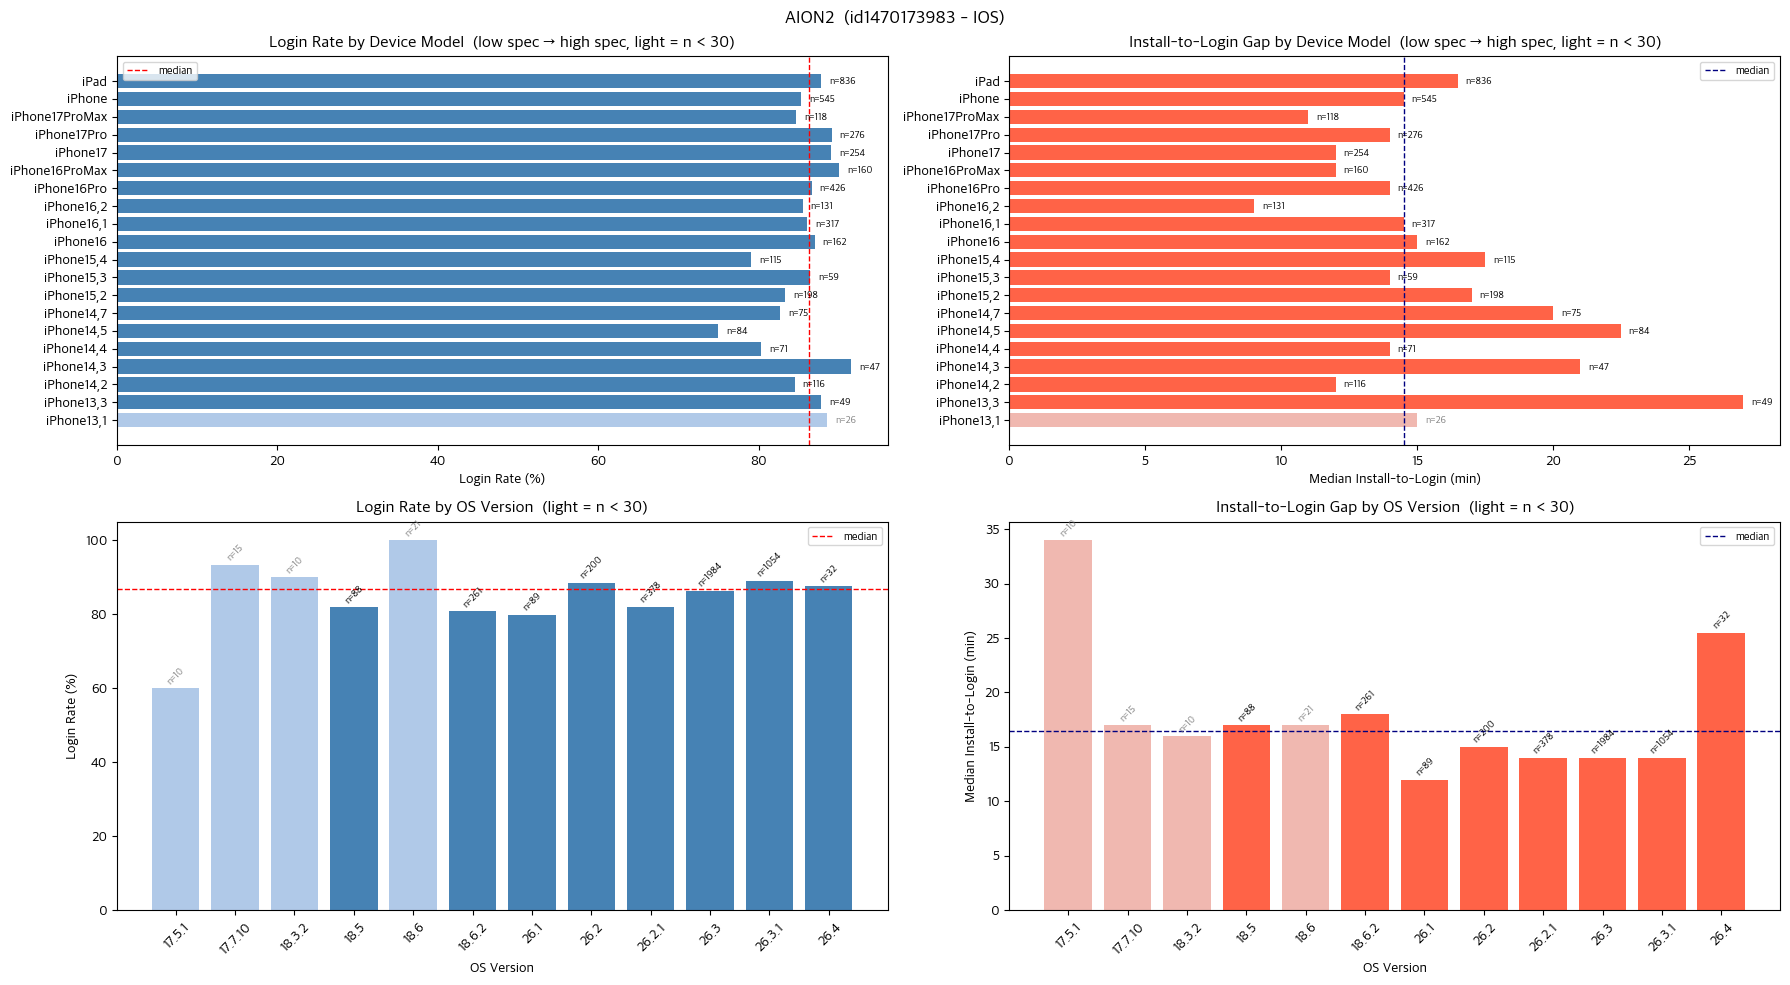

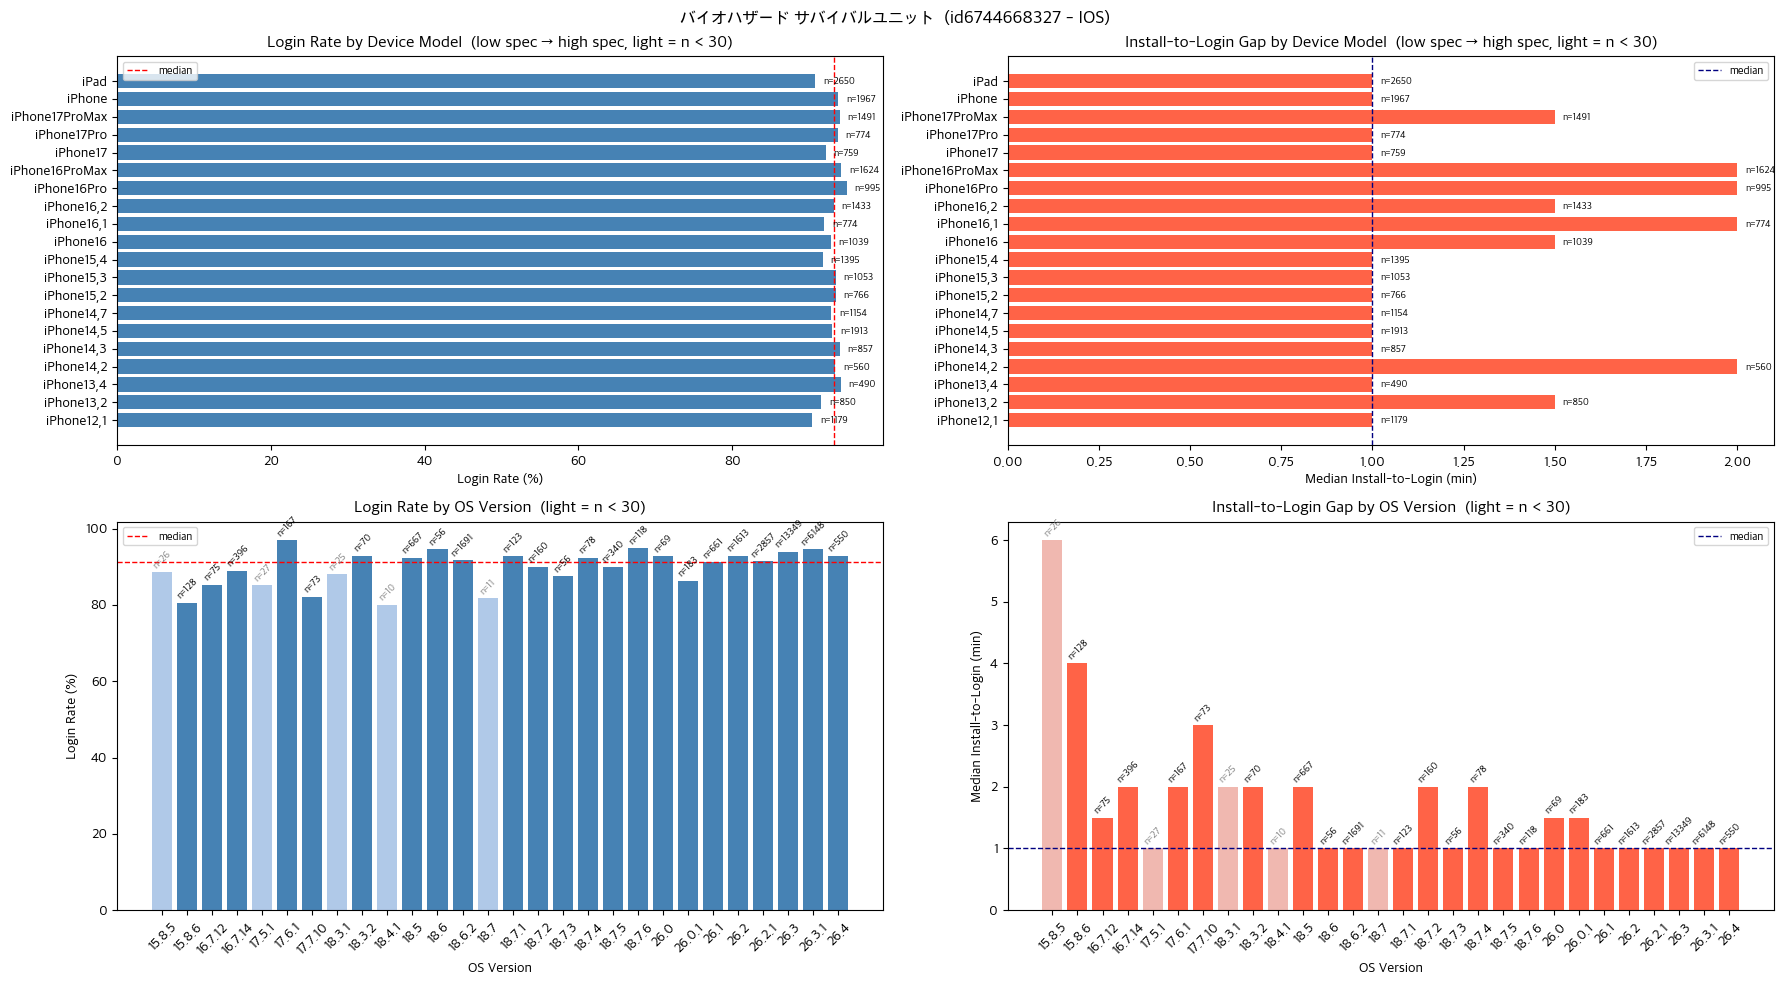

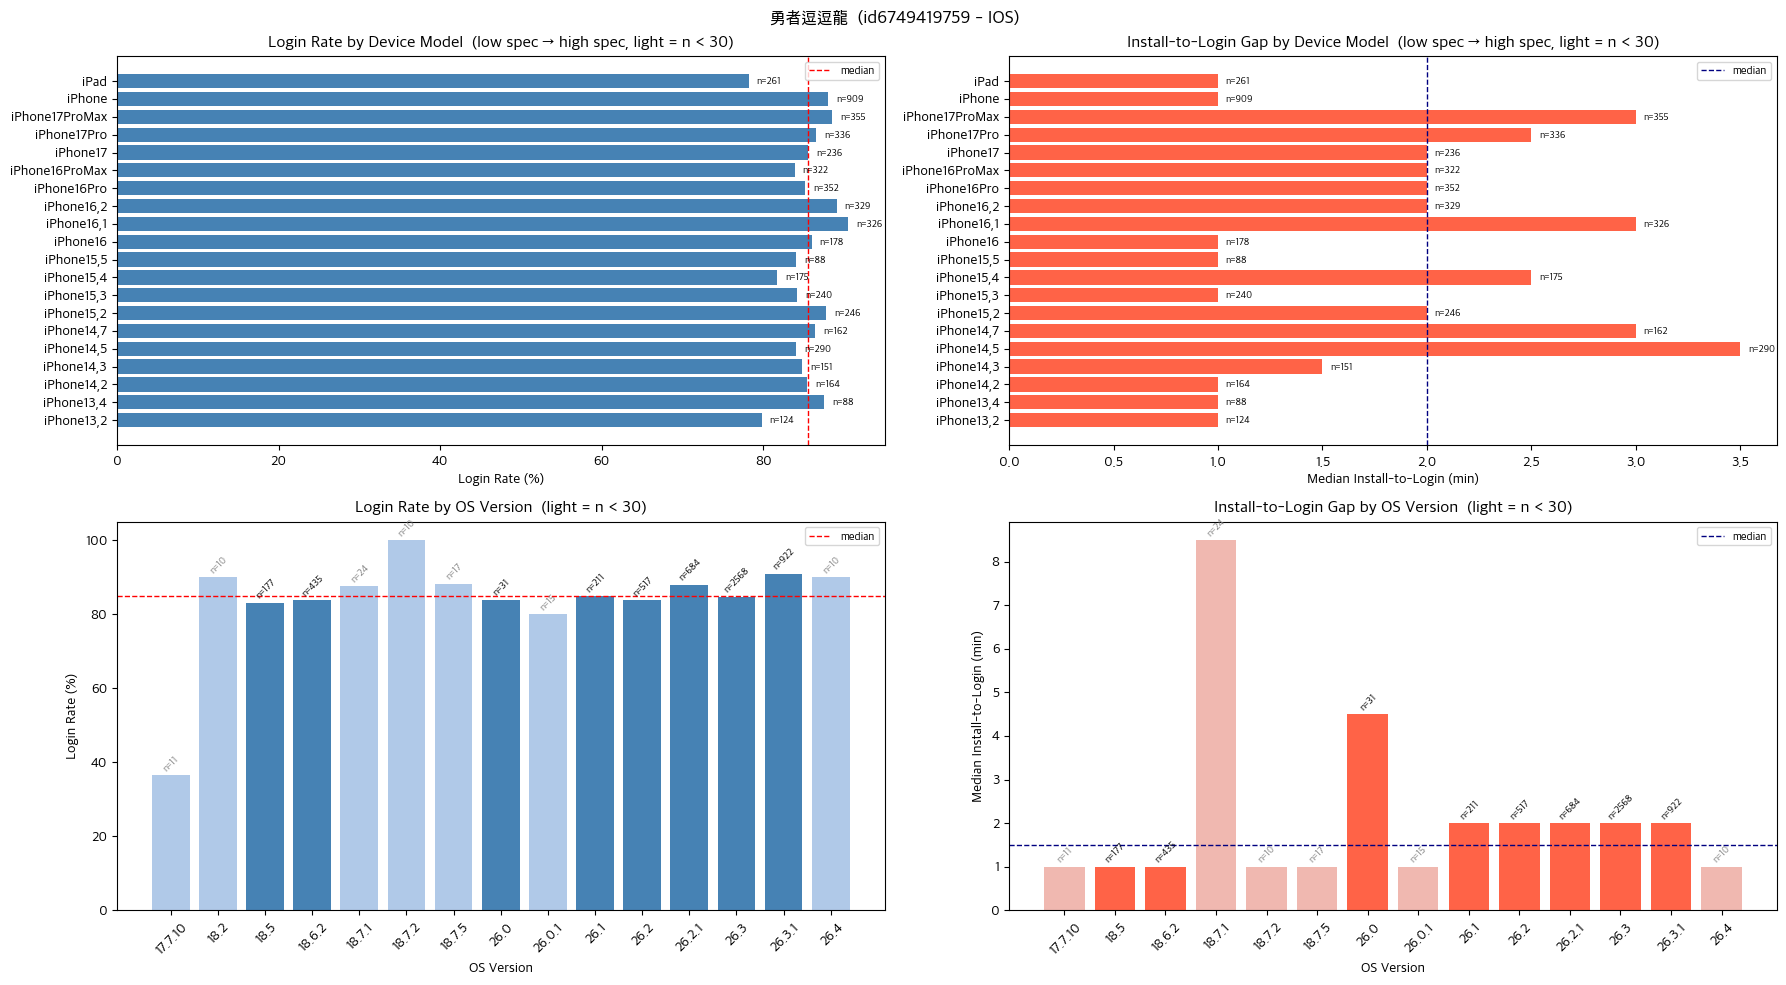

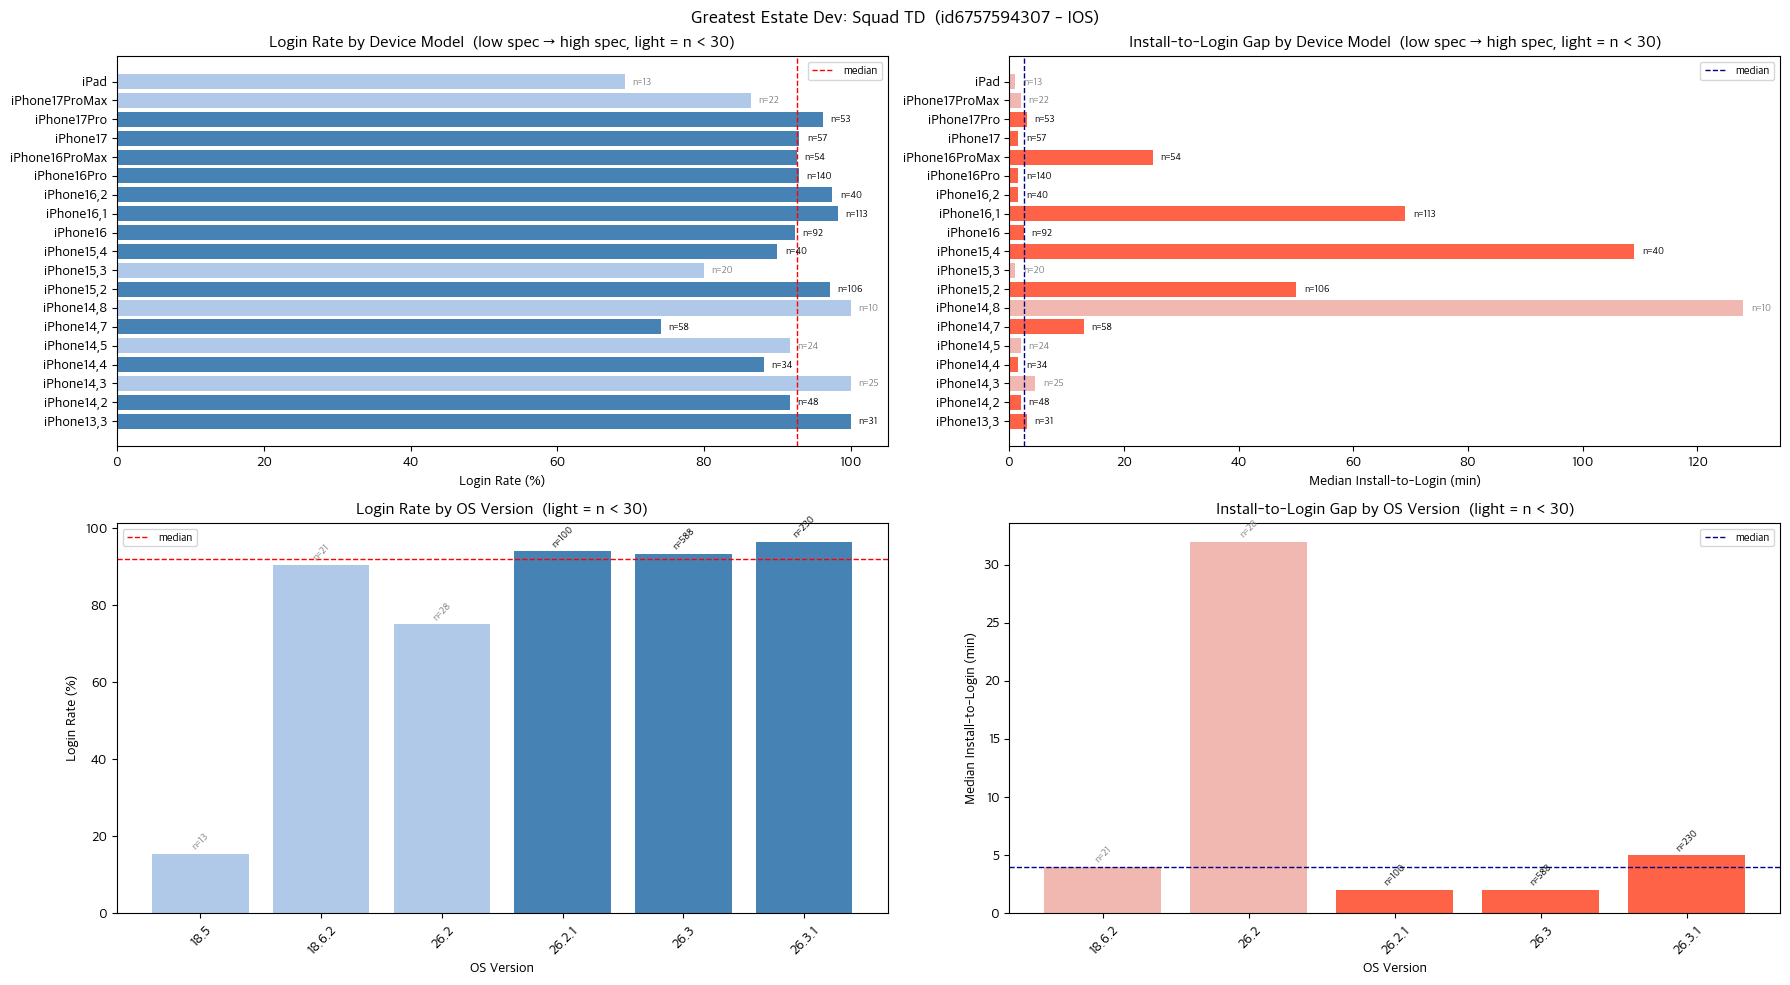

In [124]:
# Section 3: Charts by device_model and OS version -- per bundle
# Each bundle: 4 subplots (2 dims x 2 metrics)
# Device axis sorted low-spec → high-spec; n= annotated on every bar; light bars = n < 30

import re

# Hardcoded heavy-download bundles (identified in Section 1-2 gap event analysis)
HEAVY_DOWNLOAD_BUNDLES = [
    'id1470173983',   # AION2 -- CDN_E, CDN_S
    'id6749419759',   # *** -- start_loading, finish_loading
    'id6744668327',   # Biohazard -- Additional download_Complete
    'id6757594307',   # Greatest Estate Developer -- base_loading
]
LOW_N_THRESHOLD = 30   # bars with install_users < this are shaded lighter

df_device_heavy = df_device[df_device['mmp_bundle_id'].isin(HEAVY_DOWNLOAD_BUNDLES)].copy()
print(f'Bundles in chart data: {df_device_heavy["mmp_bundle_id"].nunique()} -- {sorted(df_device_heavy["mmp_bundle_id"].unique())}')

# Non-English font support
import matplotlib.font_manager as fm

def set_unicode_font():
    candidates = [
        'Apple SD Gothic Neo', 'AppleGothic',
        'Noto Sans CJK KR', 'Noto Sans KR',
        'Malgun Gothic',
        'Hiragino Sans', 'Hiragino Kaku Gothic Pro',
        'DejaVu Sans',
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            print(f'Font set: {font}')
            return
    print('Warning: no CJK font found')

set_unicode_font()
plt.rcParams['axes.unicode_minus'] = False

TOP_N_DEVICES = 20

def spec_rank(model):
    """Return a numeric spec rank for sorting iPhone/iPad models low→high.
    iPhone{gen},{variant} internal IDs: rank = gen + variant*0.1
    Named display models (iPhone16Pro etc.): mapped manually.
    iPad: mid-range placeholder (~iPhone13 era).
    """
    named = {
        'iPhone16':       15.7,   # iPhone 16 base (marketing name) → slots between iPhone15,5 and iPhone16,1
        'iPhone16Pro':    16.3,   # iPhone 16 Pro (hardware: ~iPhone17,1)
        'iPhone16ProMax': 16.4,   # iPhone 16 Pro Max (hardware: ~iPhone17,2)
        'iPhone17':       17.0,   # iPhone 17 base (2025)
        'iPhone17Pro':    17.3,
        'iPhone17ProMax': 17.4,
    }
    if model in named:
        return named[model]
    m = re.match(r'iPhone(\d+),(\d+)', model)
    if m:
        return int(m.group(1)) + int(m.group(2)) * 0.1
    if 'iPad' in model:
        return 130.0   # roughly iPhone13-era performance
    if model == 'iPhone':
        return 100.0   # generic label → treat as older
    return 0.0

def bar_colors(n_series, full_color, low_color):
    return [low_color if n < LOW_N_THRESHOLD else full_color for n in n_series]

for bundle_id, grp in df_device_heavy.groupby('mmp_bundle_id'):
    app_name = grp['app_name'].iloc[0]
    os_label = grp['os'].iloc[0]

    # Aggregate by device_model, add spec rank, sort low→high spec
    by_model = (
        grp.groupby('device_model').agg(
            install_users=('install_users', 'sum'),
            login_users=('login_users', 'sum'),
            median_gap=('median_install_to_login_min', 'median'),
        ).assign(login_rate=lambda d: (d.login_users / d.install_users * 100).round(1))
        .nlargest(TOP_N_DEVICES, 'install_users')
    )
    by_model['spec_rank'] = by_model.index.map(spec_rank)
    by_model = by_model.sort_values('spec_rank')   # low spec bottom → high spec top

    # Aggregate by OS version (sort chronologically = low→high)
    by_osv = (
        grp.groupby('osv').agg(
            install_users=('install_users', 'sum'),
            login_users=('login_users', 'sum'),
            median_gap=('median_install_to_login_min', 'median'),
        ).assign(login_rate=lambda d: (d.login_users / d.install_users * 100).round(1))
        .sort_index()
    )

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'{app_name}  ({bundle_id} - {os_label})', fontsize=13, fontweight='bold')

    # --- [0,0] Login Rate by device model (low spec → high spec, bottom → top) ---
    colors = bar_colors(by_model['install_users'], 'steelblue', '#b0c9e8')
    axes[0, 0].barh(by_model.index, by_model['login_rate'], color=colors)
    axes[0, 0].set_xlabel('Login Rate (%)')
    axes[0, 0].set_title('Login Rate by Device Model  (low spec → high spec, light = n < 30)')
    axes[0, 0].axvline(by_model['login_rate'].median(), color='red', linestyle='--', linewidth=1, label='median')
    axes[0, 0].legend(fontsize=8)
    x_max = axes[0, 0].get_xlim()[1]
    for i, (model, row) in enumerate(by_model.iterrows()):
        axes[0, 0].text(min(row['login_rate'] + 1, x_max * 0.98), i,
                        f'n={int(row["install_users"])}',
                        va='center', ha='left', fontsize=7,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    # --- [0,1] Install-to-Login Gap by device model (same spec order) ---
    dm_gap = by_model.dropna(subset=['median_gap'])
    gap_colors = bar_colors(dm_gap['install_users'], 'tomato', '#f0b8b0')
    axes[0, 1].barh(dm_gap.index, dm_gap['median_gap'], color=gap_colors)
    axes[0, 1].set_xlabel('Median Install-to-Login (min)')
    axes[0, 1].set_title('Install-to-Login Gap by Device Model  (low spec → high spec, light = n < 30)')
    axes[0, 1].axvline(dm_gap['median_gap'].median(), color='navy', linestyle='--', linewidth=1, label='median')
    axes[0, 1].legend(fontsize=8)
    x_max_gap = axes[0, 1].get_xlim()[1]
    for i, (model, row) in enumerate(dm_gap.iterrows()):
        axes[0, 1].text(min(row['median_gap'] + x_max_gap * 0.01, x_max_gap * 0.98), i,
                        f'n={int(row["install_users"])}',
                        va='center', ha='left', fontsize=7,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    # --- [1,0] Login Rate by OS version (chronological = low→high) ---
    osv_colors = bar_colors(by_osv['install_users'], 'steelblue', '#b0c9e8')
    axes[1, 0].bar(by_osv.index.astype(str), by_osv['login_rate'], color=osv_colors)
    axes[1, 0].set_xlabel('OS Version')
    axes[1, 0].set_ylabel('Login Rate (%)')
    axes[1, 0].set_title('Login Rate by OS Version  (light = n < 30)')
    axes[1, 0].axhline(by_osv['login_rate'].median(), color='red', linestyle='--', linewidth=1, label='median')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend(fontsize=8)
    for i, (osv, row) in enumerate(by_osv.iterrows()):
        axes[1, 0].text(i, row['login_rate'] + 1, f'n={int(row["install_users"])}',
                        ha='center', fontsize=7, rotation=45,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    # --- [1,1] Install-to-Login Gap by OS version ---
    osv_gap = by_osv.dropna(subset=['median_gap'])
    osv_gap_colors = bar_colors(osv_gap['install_users'], 'tomato', '#f0b8b0')
    axes[1, 1].bar(osv_gap.index.astype(str), osv_gap['median_gap'], color=osv_gap_colors)
    axes[1, 1].set_xlabel('OS Version')
    axes[1, 1].set_ylabel('Median Install-to-Login (min)')
    axes[1, 1].set_title('Install-to-Login Gap by OS Version  (light = n < 30)')
    axes[1, 1].axhline(osv_gap['median_gap'].median(), color='navy', linestyle='--', linewidth=1, label='median')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend(fontsize=8)
    for i, (osv, row) in enumerate(osv_gap.iterrows()):
        axes[1, 1].text(i, row['median_gap'] + osv_gap['median_gap'].max() * 0.01,
                        f'n={int(row["install_users"])}',
                        ha='center', fontsize=7, rotation=45,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    plt.tight_layout()
    plt.show()
    print()


## Section 3 — Chart Interpretation: 4 Identified Heavy Titles

Summary of device/OS performance patterns for each benchmark title, and implications for 7DS Origin de-targeting.

---

### 1. AION2 (`id1470173983`) — Gap events: `CDN_E`, `CDN_S`

**Strongest benchmark for 7DS Origin.** CDN-type gap events directly confirm a large in-app asset download between install and login, matching 7DS Origin's expected 9–16GB packet.

**Device model:**
- Login rate spans ~55–95%. Older iPhone 14-series (iPhone14,4, iPhone14,5) are clearly below the median (~87%), while iPhone 15+ and 16+ series cluster at or above it.
- Install-to-login gap ranges 5–27 min. iPhone13,3 is an outlier at ~27 min, while flagship iPhone 16-series complete in ~2–5 min — consistent with faster storage/network handling large downloads more efficiently.

**OS version:**
- iOS 17.5.1 is a clear outlier: login rate drops to ~60% (vs. median ~87%) and gap time spikes to ~34 min. This indicates older devices running unsupported OS versions struggle to complete the download.
- iOS 18.x and 26.x are all near-median. No specific version in those ranges warrants exclusion.

**De-targeting recommendation for 7DS Origin:** Exclude iOS < 18. Consider flagging iPhone 14-series older sub-models (iPhone14,4, iPhone14,5) for monitoring.

---

### 2. バイオハザード サバイバルユニット (`id6744668327`) — Gap event: `Additional_download_Complete`

**Not a strong download-volume proxy, but useful for event instrumentation reference.** The single `Additional_download_Complete` gap event suggests a light or pre-cached in-app asset, not a multi-GB download.

**Device model:**
- Login rate is uniformly high across all device models (~87–100%). iPhone12,1 is the only outlier at ~70%, but even that is not dramatically below baseline.
- Install-to-login gap is extremely short — median ~1 min across all models, max ~2 min. This is inconsistent with a heavy-download profile.

**OS version:**
- Consistently high login rates across all iOS versions (85–100%), including older ones like iOS 15.8.5 (~87%).
- Gap times are uniformly short (<2 min); iOS 15.8.5 reaches ~6 min but is still minimal.

**Implication for 7DS Origin:** Biohazard shows that when the in-app download is light, device and OS version have almost no impact on login conversion. This confirms that 7DS Origin's much heavier download will amplify device/OS sensitivity significantly. The `Additional_download_Complete` event name is a useful naming convention reference for instrumenting 7DS Origin's own download completion event.

---

### 3. 勇者逗逗龍 (`id6749419759`) — Gap events: `start_loading`, `finish_loading`

**Moderate benchmark.** Loading screen events (not explicit download events) suggest a lighter or streaming-style asset load. Gap times of 1–3.5 min are too short to be a true CDN-download comparable to 7DS Origin.

**Device model:**
- Login rate range ~75–88%. iPad is the lowest (~75%), and a few iPhone 13-series models are slightly below median (~85%).
- Gap time is short (1–3.5 min); ironically, iPad has the fastest gap time (~near 0 min) despite lower login rate, suggesting login drop-off on iPad is not related to download speed.

**OS version:**
- iOS 17.7.10 has a severe login rate drop to ~37% — the worst outlier across all four titles at the OS level. This clearly flags iOS 17.x as problematic.
- iOS 18.7.1 shows a gap time spike to ~8.5 min (vs. median ~1.5 min) — likely a single-version anomaly unrelated to hardware.
- All other iOS 18.x and 26.x versions are near-median.

**De-targeting recommendation for 7DS Origin:** Corroborates the iOS < 18 exclusion. iPad lower login rate aligns with a potential iPad de-targeting signal (consistent with Biohazard's iPhone12,1 pattern).

---

### 4. Greatest Estate Dev: Squad TD (`id6757594307`) — Gap event: `base_loading`

**Highest actionable de-targeting signal.** Despite generally high login rates by device (~90–100%), this title shows the most severe OS-level issue and the widest gap time variance.

**Device model:**
- Login rate is mostly 90–100% across modern iPhone models. iPad (~72%) and iPhone14,7 (~75%) are meaningfully below the median (~93%).
- Gap time is extremely bimodal: near-zero for iPad, iPhone15,3, iPhone16Pro, iPhone17 — but up to 125 min for iPhone14,8 and ~100 min for iPhone15,4. This suggests certain device models trigger a sequential (vs. streamed) base_loading sequence that is highly download-speed dependent.

**OS version:**
- iOS 18.5 has a login rate of only ~15% — a near-zero conversion rate that almost certainly reflects a compatibility breakage (specific build incompatibility or a forced update prompt that blocked loading).
- iOS 26.2 shows a gap time spike at ~32 min (vs. median ~4 min), suggesting a specific build regression in the loading path.
- iOS 18.6.2+ and 26.x (excluding 26.2) are all healthy.

**De-targeting recommendation for 7DS Origin:** Exclude iOS 18.5 explicitly. Monitor iOS 26.2 if 7DS Origin launches on a similar engine version. Flag iPad and iPhone14,7 for bid reduction rather than full exclusion.

---

### Cross-Title Synthesis — 7DS Origin De-targeting Recommendations

| Signal | Titles | Recommendation |
|--------|--------|----------------|
| iOS < 18 (esp. 17.x) | AION2, 勇者逗逗龍 | **Exclude iOS < 18** |
| iOS 18.5 specifically | Greatest Estate Dev | **Exclude iOS 18.5** (compatibility breakage) |
| iPhone 14-series older sub-models | AION2, Greatest Estate Dev | Flag iPhone14,4, iPhone14,5, iPhone14,7 for monitoring; bid down if CPA signals confirm |
| iPad | 勇者逗逗龍, Greatest Estate Dev | Apply bid reduction on iPad; consider exclusion if login CPA exceeds 2× KRW 15,000 |
| iPhone 12-series and older | Biohazard (iPhone12,1) | Exclude iPhone 12 and older |

**Best campaign structure benchmark:** AION2 (CPI/install-optimized at launch) and Greatest Estate Dev (CPI) both ran install-goal campaigns in D0–D30. This aligns with the expectation that login CPA optimization is premature at launch for heavy-download games — install volume is needed first to understand the install→login conversion baseline before switching to CPA or ROAS goals.


## Section 4 — Android Gap Event Analysis

**Goal:** Run the same install→login gap event analysis from Section 1-2 on qualifying Android apps that confirmed `%login%` event coverage, to identify any Android heavy-download benchmarks for 7DS Origin.

**Criteria used to identify these 9 apps (pre-computed via BQ, 2026-03-10):**
1. **Genre:** `moloco.genre IN ('rpg', 'strategy')` in `dim1_app` + `os = 'ANDROID'`
2. **Release date:** within the past 12 months of `2026-03-10`
3. **Moloco spend:** >$15K total in D0–D30 launch window (`fact_dsp_core`)
4. **Login event confirmed:** `LOWER(event.name) LIKE '%login%'` observed in `focal-elf-631.df_accesslog.pb` in the 7-day window ending 2026-03-10 (with `pb.attribution.attributed = TRUE`)

> **Note:** Gap event and device/OS analysis below uses the **D0–D30 window from each app's release date** — the period when fresh installs actually occurred. These apps' Moloco campaigns ran in 2025; no new attributed installs exist in recent pb data. Query scan cost: ~20 TB.

19 Android apps passed filters 1–3. Of those, **9 had login events visible in the past 7 days**; the remaining 10 have no login MMP event configured (or use a different event name).

| Bundle | App | Genre | Release | D0–D30 Spend |
|--------|-----|-------|---------|--------------|
| `com.funcat.tgbtcru` | Tokyo Ghoul: Break The Chains | rpg | 2025-06-11 | $31,905 |
| `com.gf.wafh5krkr.hwyad.google` | 오피스 퀸 키우기 | rpg | 2025-05-06 | $75,065 |
| `com.wishhex.honey` | Hex & Honey | rpg | 2025-06-07 | $67,441 |
| `com.marsru.refantasia.android` | Refantasia | strategy | 2025-06-06 | $22,328 |
| `com.dungeonbattle2.android` | 손가락 나갔다: 던전팡팡 | rpg | 2025-07-03 | $16,313 |
| `com.global.lootru` | Lootborn Warriors (RU) | rpg | 2025-06-04 | $65,074 |
| `com.global.loot` | Lootborn Warriors | rpg | 2025-06-04 | $67,053 |
| `com.pergame.starlitedenru` | Stellar Sanctuary | strategy | 2025-08-07 | $18,750 |
| `com.kingkongsoft.sh4.g` | 용칼이 키우기 | rpg | 2025-07-01 | $19,924 |

In [ ]:
# Section 4: Gap event analysis for 9 qualifying Android apps with confirmed login events
# Uses D0-D30 window from each app's release date — this is when fresh installs occurred.
# Moloco campaigns for these apps ran in 2025; no new attributed installs exist in recent pb.
# Cost: ~20 TB (same regardless of D7/D14/D30 due to fixed partition range 2025-05-01 to 2025-09-10)

ANDROID_BUNDLE_LIST = [
    'com.funcat.tgbtcru',            # Tokyo Ghoul: Break The Chains
    'com.gf.wafh5krkr.hwyad.google', # 오피스 퀸 키우기
    'com.wishhex.honey',             # Hex & Honey
    'com.marsru.refantasia.android', # Refantasia
    'com.dungeonbattle2.android',    # 손가락 나갔다: 던전팡팡
    'com.global.lootru',             # Lootborn Warriors (RU)
    'com.global.loot',               # Lootborn Warriors
    'com.pergame.starlitedenru',     # Stellar Sanctuary
    'com.kingkongsoft.sh4.g',        # 용칼이 키우기
]
android_bundles_in = ', '.join(f"\'{b}\'" for b in ANDROID_BUNDLE_LIST)

query_android_gap = f"""
WITH

qualifying_apps AS (
  SELECT *
  FROM UNNEST([
    STRUCT('com.funcat.tgbtcru'             AS bundle_id, 'Tokyo Ghoul: Break The Chains' AS app_name, DATE('2025-06-11') AS release_date),
    STRUCT('com.gf.wafh5krkr.hwyad.google'  AS bundle_id, '오피스 퀸 키우기'               AS app_name, DATE('2025-05-06') AS release_date),
    STRUCT('com.wishhex.honey'              AS bundle_id, 'Hex & Honey'                   AS app_name, DATE('2025-06-07') AS release_date),
    STRUCT('com.marsru.refantasia.android'  AS bundle_id, 'Refantasia'                    AS app_name, DATE('2025-06-06') AS release_date),
    STRUCT('com.dungeonbattle2.android'     AS bundle_id, '손가락 나갔다: 던전팡팡'         AS app_name, DATE('2025-07-03') AS release_date),
    STRUCT('com.global.lootru'              AS bundle_id, 'Lootborn Warriors (RU)'        AS app_name, DATE('2025-06-04') AS release_date),
    STRUCT('com.global.loot'               AS bundle_id, 'Lootborn Warriors'             AS app_name, DATE('2025-06-04') AS release_date),
    STRUCT('com.pergame.starlitedenru'      AS bundle_id, 'Stellar Sanctuary'             AS app_name, DATE('2025-08-07') AS release_date),
    STRUCT('com.kingkongsoft.sh4.g'         AS bundle_id, '용칼이 키우기'                  AS app_name, DATE('2025-07-01') AS release_date)
  ]) AS t
),

-- Scan D0-D30 from each app's release date — covers the actual launch install period
pb_events AS (
  SELECT
    qa.bundle_id,
    qa.app_name,
    qa.release_date,
    CASE
      WHEN pb.device.idfa IS NOT NULL AND pb.device.idfa NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN pb.device.idfa
      WHEN pb.mmp.device_id IS NOT NULL AND pb.mmp.device_id != '' THEN pb.mmp.device_id
      ELSE NULL
    END AS user_id,
    pb.event.name         AS event_name,
    pb.event.event_at     AS event_at,
    pb.event.install_at   AS install_at
  FROM `focal-elf-631.df_accesslog.pb` pb
  INNER JOIN qualifying_apps qa
    ON  pb.app.bundle = qa.bundle_id
    AND DATE(pb.timestamp) BETWEEN qa.release_date
                                AND DATE_ADD(qa.release_date, INTERVAL 30 DAY)
  WHERE DATE(pb.timestamp) BETWEEN '2025-05-01' AND '2025-09-15'
    AND pb.attribution.attributed = TRUE
    AND pb.app.bundle IN ({android_bundles_in})
),

install_cohort AS (
  -- Fresh installs during D0-D30 launch window
  SELECT bundle_id, app_name, user_id,
    MIN(COALESCE(install_at, event_at)) AS install_time
  FROM pb_events
  WHERE event_name = 'install'
    AND user_id IS NOT NULL
  GROUP BY 1, 2, 3
),

user_logins AS (
  SELECT bundle_id, user_id,
    MIN(event_at) AS first_login_time
  FROM pb_events
  WHERE LOWER(event_name) LIKE '%login%' AND user_id IS NOT NULL
  GROUP BY 1, 2
),

install_login_rate AS (
  SELECT
    c.bundle_id,
    COUNT(DISTINCT c.user_id) AS install_users,
    COUNT(DISTINCT l.user_id) AS login_users
  FROM install_cohort c
  LEFT JOIN user_logins l USING (bundle_id, user_id)
  GROUP BY 1
),

user_journey AS (
  SELECT
    c.bundle_id, c.user_id,
    c.install_time,
    l.first_login_time,
    TIMESTAMP_DIFF(l.first_login_time, c.install_time, MINUTE) AS install_to_login_min
  FROM install_cohort c
  INNER JOIN user_logins l USING (bundle_id, user_id)
  WHERE l.first_login_time > c.install_time
    AND TIMESTAMP_DIFF(l.first_login_time, c.install_time, MINUTE) BETWEEN 1 AND 1440
),

gap_events AS (
  SELECT e.bundle_id, e.user_id, e.event_name
  FROM pb_events e
  INNER JOIN user_journey uj USING (bundle_id, user_id)
  WHERE e.event_name != 'install'
    AND LOWER(e.event_name) NOT LIKE '%login%'
    AND e.event_at > uj.install_time
    AND e.event_at < uj.first_login_time
),

gap_summary AS (
  SELECT
    bundle_id,
    COUNT(DISTINCT user_id)                                   AS journey_users,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(50)]  AS median_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(75)]  AS p75_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(90)]  AS p90_install_to_login_min
  FROM user_journey
  GROUP BY 1
),

app_gap_events AS (
  SELECT
    bundle_id,
    TRUE AS has_gap_events,
    STRING_AGG(DISTINCT event_name, ', ' ORDER BY event_name) AS gap_event_types
  FROM gap_events
  GROUP BY 1
)

SELECT
  qa.app_name,
  qa.bundle_id,
  'ANDROID'                                                              AS os,
  qa.release_date,
  r.install_users,
  r.login_users,
  ROUND(SAFE_DIVIDE(r.login_users, NULLIF(r.install_users, 0)) * 100, 1) AS first_login_rate_pct,
  COALESCE(ge.has_gap_events, FALSE)                                      AS has_gap_events,
  ge.gap_event_types,
  s.median_install_to_login_min,
  s.p75_install_to_login_min,
  s.p90_install_to_login_min,
  s.journey_users                                                         AS gap_journey_user_count
FROM qualifying_apps qa
LEFT JOIN install_login_rate r  USING (bundle_id)
LEFT JOIN gap_summary s         USING (bundle_id)
LEFT JOIN app_gap_events ge     USING (bundle_id)
ORDER BY s.median_install_to_login_min DESC NULLS LAST
"""

df_android_gap = run_query(query_android_gap, label='Android gap event analysis (D0-D30 launch window)')
df_android_gap


## Section 4 — Gap Analysis Interpretation

**Query window:** D0–D30 from each app's release date (launch install cohort). ~306 TB scanned.

### Key Finding: Refantasia is the Android Heavy-Download Benchmark

| App | Install→Login (P50) | P75 | P90 | Login Rate | Gap Events |
|-----|---------------------|-----|-----|------------|------------|
| **Refantasia** | **92 min** | 531 min | 867 min | 96.8% | Complete-tutorials, Create a role |
| Stellar Sanctuary | 2 min | 8 min | 197 min | 98.2% | ResourceDownloadStart/Failed, SSOConnect*, Level_1–6 |
| Hex & Honey | 2 min | 17 min | 383 min | 97.4% | *(none)* |
| 손가락 나갔다: 던전팡팡 | 2 min | 22 min | 210 min | 98.5% | click, registration |
| Tokyo Ghoul | 1 min | 5 min | 241 min | 96.4% | character, click, launch app |
| 오피스 퀸 키우기 | 1 min | 2 min | 45 min | 88.8% | createrole, register |
| Lootborn Warriors (RU) | 1 min | 13 min | 243 min | 94.7% | af_app_opened, enter_server |
| Lootborn Warriors | 1 min | 6 min | 92 min | 97.1% | af_app_opened, enter_server |
| **용칼이 키우기** | 1 min | 7 min | 223 min | **45.5%** | 20+ stage/tutorial events |

### Per-App Notes

**Refantasia** (`com.marsru.refantasia.android`) — Strategy RPG; only Android app with a heavy-download profile comparable to iOS AION2 (median 92 min vs AION2's 20+ min). Gap events (`Complete-tutorials`, `Create a role`) indicate a mandatory tutorial + character creation flow before the login event fires. Strong benchmark for 7DS Origin Android.

**Stellar Sanctuary** — Has explicit `ResourceDownloadStart` / `ResourceDownloadFailed` / `ManifestNotMatch` gap events, signaling a real asset download step. Median login gap is only 2 min (most users complete quickly), but the p90 at 197 min suggests a non-trivial heavy-download tail. `SSOConnectStart/Success` gap events indicate a social login flow after download.

**용칼이 키우기** — Unusual case: median gap is 1 min but login rate is only 45.5% (lowest in the cohort). The 20+ gap events (Stage_5 through Stage_55, tier events, tutorial_start) fire *before* the login event — suggesting the 'login' event may be tied to a milestone far into the game, not the first session login. Not representative as a benchmark.

**Remaining 6 apps** — All show median ≤ 2 min with high login rates (88–98%). These are lightweight-download titles where users reach first login almost immediately.

### Implication for 7DS Origin

**Refantasia** is the recommended Android benchmark for bidding conservatism recommendations:
- Median 92-min gap → exclude users who haven't logged in within 2 hours of install
- Gap events suggest a download + tutorial funnel; CPD-style optimization should wait for post-tutorial signals
- No iOS equivalent needed; 7DS Origin Android can use Refantasia's gap profile for de-targeting window sizing


In [ ]:
# Section 4: Device/OS performance for qualifying Android apps
# Sorted by login_rate ASC (worst performers first) within each bundle
# pb.attribution.attributed = TRUE consistent with gap event cell above

android_heavy_structs = ',\n'.join(
    f"    STRUCT('{b}' AS mmp_bundle_id, 'ANDROID' AS os)" for b in ANDROID_BUNDLE_LIST
)

query_android_device = f"""
WITH android_apps AS (
  SELECT *
  FROM UNNEST([
{android_heavy_structs}
  ]) AS t
),

pb_events AS (
  SELECT
    aa.mmp_bundle_id,
    CASE
      WHEN pb.device.idfa IS NOT NULL AND pb.device.idfa NOT IN ('', '00000000-0000-0000-0000-000000000000') THEN pb.device.idfa
      WHEN pb.mmp.device_id IS NOT NULL AND pb.mmp.device_id != '' THEN pb.mmp.device_id
      ELSE NULL
    END AS user_id,
    pb.device.model       AS device_model,
    pb.device.osv         AS osv,
    pb.event.name         AS event_name,
    pb.event.event_at     AS event_at,
    pb.event.install_at   AS install_at
  FROM `focal-elf-631.df_accesslog.pb` pb
  INNER JOIN android_apps aa ON pb.app.bundle = aa.mmp_bundle_id
  INNER JOIN (
    SELECT bundle_id, release_date FROM UNNEST([
      STRUCT('com.funcat.tgbtcru'             AS bundle_id, DATE('2025-06-11') AS release_date),
      STRUCT('com.gf.wafh5krkr.hwyad.google'  AS bundle_id, DATE('2025-05-06') AS release_date),
      STRUCT('com.wishhex.honey'              AS bundle_id, DATE('2025-06-07') AS release_date),
      STRUCT('com.marsru.refantasia.android'  AS bundle_id, DATE('2025-06-06') AS release_date),
      STRUCT('com.dungeonbattle2.android'     AS bundle_id, DATE('2025-07-03') AS release_date),
      STRUCT('com.global.lootru'              AS bundle_id, DATE('2025-06-04') AS release_date),
      STRUCT('com.global.loot'               AS bundle_id, DATE('2025-06-04') AS release_date),
      STRUCT('com.pergame.starlitedenru'      AS bundle_id, DATE('2025-08-07') AS release_date),
      STRUCT('com.kingkongsoft.sh4.g'         AS bundle_id, DATE('2025-07-01') AS release_date)
    ]) AS t
  ) rd ON rd.bundle_id = aa.mmp_bundle_id
         AND DATE(pb.timestamp) BETWEEN rd.release_date
                                    AND DATE_ADD(rd.release_date, INTERVAL 30 DAY)
  WHERE DATE(pb.timestamp) BETWEEN '2025-05-01' AND '2025-09-15'
    AND pb.attribution.attributed = TRUE
    AND pb.app.bundle IN ({android_bundles_in})
),

install_cohort AS (
  SELECT mmp_bundle_id, user_id, device_model, osv,
    MIN(COALESCE(install_at, event_at)) AS install_time
  FROM pb_events
  WHERE event_name = 'install'
    AND user_id IS NOT NULL
  GROUP BY 1, 2, 3, 4
),

user_logins AS (
  SELECT mmp_bundle_id, user_id, MIN(event_at) AS first_login_time
  FROM pb_events
  WHERE LOWER(event_name) LIKE '%login%' AND user_id IS NOT NULL
  GROUP BY 1, 2
),

login_rate_by_device AS (
  SELECT
    c.mmp_bundle_id, c.device_model, c.osv,
    COUNT(DISTINCT c.user_id)   AS install_users,
    COUNT(DISTINCT l.user_id)   AS login_users,
    ROUND(SAFE_DIVIDE(COUNT(DISTINCT l.user_id), COUNT(DISTINCT c.user_id)) * 100, 1) AS login_rate_pct
  FROM install_cohort c
  LEFT JOIN user_logins l USING (mmp_bundle_id, user_id)
  GROUP BY 1, 2, 3
),

user_journey AS (
  SELECT
    c.mmp_bundle_id, c.user_id, c.device_model, c.osv,
    TIMESTAMP_DIFF(l.first_login_time, c.install_time, MINUTE) AS install_to_login_min
  FROM install_cohort c
  INNER JOIN user_logins l USING (mmp_bundle_id, user_id)
  WHERE l.first_login_time > c.install_time
    AND TIMESTAMP_DIFF(l.first_login_time, c.install_time, MINUTE) BETWEEN 1 AND 1440
),

gap_summary AS (
  SELECT mmp_bundle_id, device_model, osv,
    COUNT(DISTINCT user_id)                                    AS journey_users,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(50)]   AS median_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(75)]   AS p75_install_to_login_min,
    APPROX_QUANTILES(install_to_login_min, 100)[OFFSET(90)]   AS p90_install_to_login_min
  FROM user_journey
  GROUP BY 1, 2, 3
)

SELECT
  r.mmp_bundle_id,
  r.device_model,
  r.osv,
  r.install_users,
  r.login_users,
  r.login_rate_pct,
  s.journey_users,
  s.median_install_to_login_min,
  s.p75_install_to_login_min,
  s.p90_install_to_login_min
FROM login_rate_by_device r
LEFT JOIN gap_summary s USING (mmp_bundle_id, device_model, osv)
WHERE r.install_users >= 5
ORDER BY r.mmp_bundle_id, r.login_rate_pct ASC
"""

df_android_device = run_query(query_android_device, label='Android device/OS performance')
for col in ['login_rate_pct', 'median_install_to_login_min', 'p75_install_to_login_min', 'p90_install_to_login_min']:
    if col in df_android_device.columns:
        df_android_device[col] = df_android_device[col].astype(float)
print(f'Bundles: {df_android_device["mmp_bundle_id"].nunique()}, rows: {len(df_android_device)}')
df_android_device.head(10)


In [ ]:
# Section 4: Device/OS charts for Android apps (same layout as Section 3)
# Android: no spec-rank sorting — sort by install_users volume (most-used devices first, bottom→top)

# Only chart bundles that have enough device-level data
ANDROID_CHART_BUNDLES = df_android_gap[
    df_android_gap['install_users'].fillna(0) >= 30
]['bundle_id'].tolist()
print(f'Bundles with enough data for charts: {ANDROID_CHART_BUNDLES}')

# Build app_name lookup from df_android_gap
app_name_map = df_android_gap.set_index('bundle_id')['app_name'].to_dict()

for bundle_id in ANDROID_CHART_BUNDLES:
    grp = df_android_device[df_android_device['mmp_bundle_id'] == bundle_id].copy()
    if grp.empty:
        continue
    app_name = app_name_map.get(bundle_id, bundle_id)

    # Aggregate by device_model (top 20 by install volume, sorted volume ascending = bottom→top)
    by_model = (
        grp.groupby('device_model').agg(
            install_users=('install_users', 'sum'),
            login_users=('login_users', 'sum'),
            median_gap=('median_install_to_login_min', 'median'),
        ).assign(login_rate=lambda d: (d.login_users / d.install_users * 100).round(1))
        .nlargest(20, 'install_users')
        .sort_values('install_users')   # low volume at bottom, high volume at top
    )

    # Aggregate by OS version
    by_osv = (
        grp.groupby('osv').agg(
            install_users=('install_users', 'sum'),
            login_users=('login_users', 'sum'),
            median_gap=('median_install_to_login_min', 'median'),
        ).assign(login_rate=lambda d: (d.login_users / d.install_users * 100).round(1))
        .sort_index()
    )

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'{app_name}  ({bundle_id} - ANDROID)', fontsize=13, fontweight='bold')

    # [0,0] Login Rate by device model
    colors = bar_colors(by_model['install_users'], 'steelblue', '#b0c9e8')
    axes[0, 0].barh(by_model.index, by_model['login_rate'], color=colors)
    axes[0, 0].set_xlabel('Login Rate (%)')
    axes[0, 0].set_title('Login Rate by Device Model  (sorted by volume, light = n < 30)')
    axes[0, 0].axvline(by_model['login_rate'].median(), color='red', linestyle='--', linewidth=1, label='median')
    axes[0, 0].legend(fontsize=8)
    x_max = axes[0, 0].get_xlim()[1]
    for i, (model, row) in enumerate(by_model.iterrows()):
        axes[0, 0].text(min(row['login_rate'] + 1, x_max * 0.98), i,
                        f'n={int(row["install_users"])}',
                        va='center', ha='left', fontsize=7,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    # [0,1] Gap by device model
    dm_gap = by_model.dropna(subset=['median_gap'])
    gap_colors_dm = bar_colors(dm_gap['install_users'], 'tomato', '#f0b8b0')
    axes[0, 1].barh(dm_gap.index, dm_gap['median_gap'], color=gap_colors_dm)
    axes[0, 1].set_xlabel('Median Install-to-Login (min)')
    axes[0, 1].set_title('Install-to-Login Gap by Device Model  (light = n < 30)')
    axes[0, 1].axvline(dm_gap['median_gap'].median(), color='navy', linestyle='--', linewidth=1, label='median')
    axes[0, 1].legend(fontsize=8)
    x_max_gap = axes[0, 1].get_xlim()[1]
    for i, (model, row) in enumerate(dm_gap.iterrows()):
        axes[0, 1].text(min(row['median_gap'] + x_max_gap * 0.01, x_max_gap * 0.98), i,
                        f'n={int(row["install_users"])}',
                        va='center', ha='left', fontsize=7,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    # [1,0] Login Rate by OS version
    osv_colors = bar_colors(by_osv['install_users'], 'steelblue', '#b0c9e8')
    axes[1, 0].bar(by_osv.index.astype(str), by_osv['login_rate'], color=osv_colors)
    axes[1, 0].set_xlabel('Android OS Version')
    axes[1, 0].set_ylabel('Login Rate (%)')
    axes[1, 0].set_title('Login Rate by OS Version  (light = n < 30)')
    axes[1, 0].axhline(by_osv['login_rate'].median(), color='red', linestyle='--', linewidth=1, label='median')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend(fontsize=8)
    for i, (osv, row) in enumerate(by_osv.iterrows()):
        axes[1, 0].text(i, row['login_rate'] + 1, f'n={int(row["install_users"])}',
                        ha='center', fontsize=7, rotation=45,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    # [1,1] Gap by OS version
    osv_gap = by_osv.dropna(subset=['median_gap'])
    osv_gap_colors = bar_colors(osv_gap['install_users'], 'tomato', '#f0b8b0')
    axes[1, 1].bar(osv_gap.index.astype(str), osv_gap['median_gap'], color=osv_gap_colors)
    axes[1, 1].set_xlabel('Android OS Version')
    axes[1, 1].set_ylabel('Median Install-to-Login (min)')
    axes[1, 1].set_title('Install-to-Login Gap by OS Version  (light = n < 30)')
    axes[1, 1].axhline(osv_gap['median_gap'].median(), color='navy', linestyle='--', linewidth=1, label='median')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend(fontsize=8)
    for i, (osv, row) in enumerate(osv_gap.iterrows()):
        axes[1, 1].text(i, row['median_gap'] + osv_gap['median_gap'].max() * 0.01,
                        f'n={int(row["install_users"])}',
                        ha='center', fontsize=7, rotation=45,
                        color='gray' if row['install_users'] < LOW_N_THRESHOLD else 'black')

    plt.tight_layout()
    plt.show()
    print()
